In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

### Get File path and load the csv data

In [2]:
from util.data_path import cassava_price_avg as data_prices

In [3]:
wide = pd.read_csv(data_prices)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [4]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [5]:
SEQ_LEN = 12
PRED_LEN = 12

### Training the Transformer Model

In [6]:
from util.transformer_cust_class import SeqDataset, TransformerRegressor

In [7]:
series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [8]:
EPOCHS = 500
for epoch in range(1, EPOCHS + 1):
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model_tf(xb)  # (B, 12)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — loss = {loss.item():.6f}")


Epoch  50/500 — loss = 0.039309
Epoch 100/500 — loss = 0.027320
Epoch 150/500 — loss = 0.022431
Epoch 200/500 — loss = 0.018841
Epoch 250/500 — loss = 0.014862
Epoch 300/500 — loss = 0.013487
Epoch 350/500 — loss = 0.010532
Epoch 400/500 — loss = 0.008899
Epoch 450/500 — loss = 0.007443
Epoch 500/500 — loss = 0.006828


### Predict the data for the next year

In [9]:
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

### Compare The Error of a predicted data and the actual data in a table format

In [13]:
error = future["price"] - tf_forecast
abs_error = abs(error)
mae_tf = mean_absolute_error(future["price"], tf_forecast)
print(f"\nTransformer MAE 2567 = {mae_tf:.4f}")


error = pd.DataFrame(
    {
        "actual": future["price"],
        "tf_forecast": tf_forecast,
        "mae_tf": abs_error,
    }
)
print(error.round(3))
print(f"mean absolute error = {mae_tf:.4f}")

print(f"Transformer Accuracy = {100 - (mae_tf / future['price'].mean() * 100):.2f}%")


Transformer MAE 2567 = 0.4023
            actual  tf_forecast  mae_tf
2024-01-01    3.65        3.380   0.270
2024-02-01    3.65        3.263   0.387
2024-03-01    3.57        3.215   0.355
2024-04-01    3.24        3.113   0.127
2024-05-01    3.19        3.037   0.153
2024-06-01    3.09        3.084   0.006
2024-07-01    3.06        3.237   0.177
2024-08-01    2.95        3.279   0.329
2024-09-01    2.86        3.326   0.466
2024-10-01    2.65        3.387   0.737
2024-11-01    2.60        3.398   0.798
2024-12-01    2.32        3.343   1.023
mean absolute error = 0.4023
Transformer Accuracy = 86.89%


### Plot The predicted data compare to an actual data

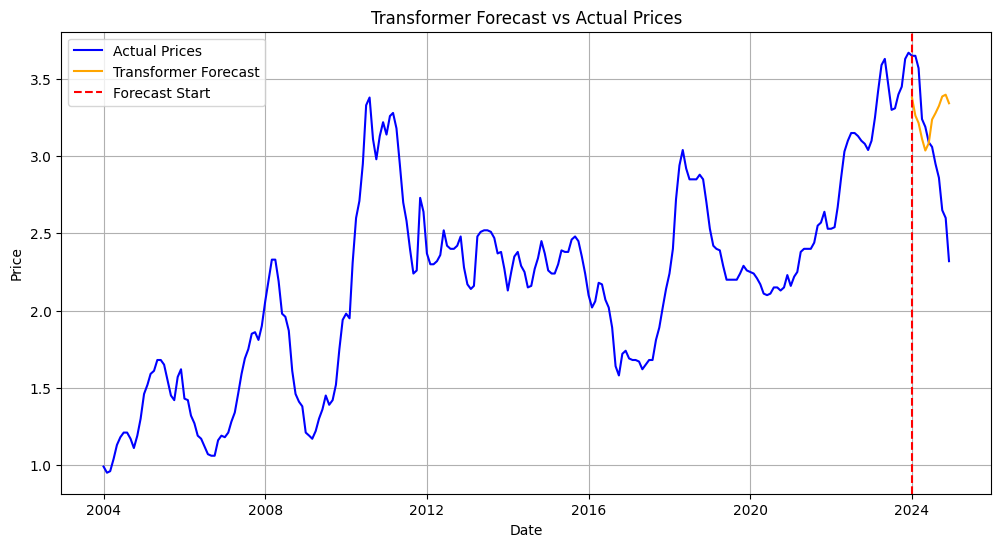

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title("Transformer Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()